<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/sensi_agent_cta_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# [CELL 1 - HTA Mentoring State Machine, Data Models & Prompt Compiler]

from enum import Enum
from dataclasses import dataclass, field
from typing import List, Dict, Optional

class HTAStage(Enum):
    STAGE_1_RAPPORT_DISCOVERY = "1.0_RAPPORT_DISCOVERY"
    STAGE_2_GOAL_CLARIFICATION = "2.0_GOAL_CLARIFICATION"
    STAGE_3_REFLECTIVE_INQUIRY = "3.0_REFLECTIVE_INQUIRY"
    STAGE_4_ACTIONABLE_STRATEGY = "4.0_ACTIONABLE_STRATEGY"
    STAGE_5_FEEDBACK_MILESTONE = "5.0_FEEDBACK_MILESTONE"

@dataclass
class UserProfile:
    user_id: str
    background: str                     # e.g., "BS in Computer Science"
    stated_career_goal: str             # e.g., "PhD Student in AI / HCI"
    identified_gaps: List[str] = field(default_factory=list)
    key_strengths: List[str] = field(default_factory=list)

@dataclass
class MentoringSessionState:
    profile: UserProfile
    current_stage: HTAStage = HTAStage.STAGE_1_RAPPORT_DISCOVERY
    dialogue_history: List[Dict[str, str]] = field(default_factory=list)
    turn_count: int = 0


class CTAPromptCompiler:
    """
    Translates HTA mentor strategy sub-goals into strict System Prompt
    constraints for LLM execution at each stage of dialogue.
    """

    BASE_SYSTEM_PERSONA = (
        "You are SENSi, an expert career mentor guided by Cognitive Task Analysis. "
        "Your primary objective is to guide the mentee through structured self-reflection "
        "and actionable career development. Do NOT deliver generic, ungrounded advice."
    )

    STAGE_DIRECTIVES = {
        HTAStage.STAGE_1_RAPPORT_DISCOVERY: (
            "SUB-GOAL 1.0 (Rapport & Discovery):\n"
            "- Acknowledge the user's specific background and validate their career goal.\n"
            "- Ask 1 open-ended discovery question about their current projects or interests.\n"
            "- CONSTRAINT: Do NOT provide roadmaps or action items yet."
        ),
        HTAStage.STAGE_2_GOAL_CLARIFICATION: (
            "SUB-GOAL 2.0 (Goal Clarification):\n"
            "- Probe the specific sub-domain or niche within their target career path.\n"
            "- Identify hands-on experience levels and concrete technical skills.\n"
            "- CONSTRAINT: Keep focus on narrowing down vague aspirations."
        ),
        HTAStage.STAGE_3_REFLECTIVE_INQUIRY: (
            "SUB-GOAL 3.0 (Reflective Inquiry):\n"
            "- Prompt critical self-reflection regarding technical strengths vs. existing gaps.\n"
            "- Ask how they plan to address their primary skill gap.\n"
            "- CONSTRAINT: Require the user to reflect before offering your strategic advice."
        ),
        HTAStage.STAGE_4_ACTIONABLE_STRATEGY: (
            "SUB-GOAL 4.0 (Actionable Strategy):\n"
            "- Synthesize the user's background, identified strengths, and self-reflected gaps.\n"
            "- Provide a 3-step, concrete, prioritized roadmap tailored to their profile.\n"
            "- CONSTRAINT: Every step must directly reference facts gathered in previous turns."
        ),
        HTAStage.STAGE_5_FEEDBACK_MILESTONE: (
            "SUB-GOAL 5.0 (Feedback & Milestones):\n"
            "- Establish measurable 30-day milestones and evaluation criteria.\n"
            "- Offer a follow-up check-in mechanism to maintain accountability."
        )
    }

    @classmethod
    def compile_system_prompt(cls, session: MentoringSessionState) -> str:
        stage_directive = cls.STAGE_DIRECTIVES.get(session.current_stage, "")

        context_block = (
            f"\n--- MENTEE CONTEXT ---\n"
            f"Background: {session.profile.background}\n"
            f"Stated Goal: {session.profile.stated_career_goal}\n"
            f"Current Stage: {session.current_stage.value}\n"
            f"Identified Strengths: {', '.join(session.profile.key_strengths) if session.profile.key_strengths else 'Pending discovery'}\n"
            f"Identified Gaps: {', '.join(session.profile.identified_gaps) if session.profile.identified_gaps else 'Pending discovery'}\n"
            f"----------------------\n"
        )

        return f"{cls.BASE_SYSTEM_PERSONA}\n{context_block}\n--- CURRENT STAGE STRATEGY DIRECTIVE ---\n{stage_directive}"

In [17]:
# [CELL 2 - SENSi Agent Pipeline & State Transition Manager]

class SENSiAgentPipeline:
    def __init__(self, profile: UserProfile):
        self.session = MentoringSessionState(profile=profile)
        self.compiler = CTAPromptCompiler()

    def advance_stage(self):
        """State transition logic following HTA hierarchy."""
        stage_order = [
            HTAStage.STAGE_1_RAPPORT_DISCOVERY,
            HTAStage.STAGE_2_GOAL_CLARIFICATION,
            HTAStage.STAGE_3_REFLECTIVE_INQUIRY,
            HTAStage.STAGE_4_ACTIONABLE_STRATEGY,
            HTAStage.STAGE_5_FEEDBACK_MILESTONE
        ]
        curr_idx = stage_order.index(self.session.current_stage)
        if curr_idx < len(stage_order) - 1:
            self.session.current_stage = stage_order[curr_idx + 1]

    def process_turn(self, user_message: str, mock_llm_call=None) -> Dict[str, str]:
        self.session.turn_count += 1
        self.session.dialogue_history.append({"role": "user", "content": user_message})

        # Compile dynamic system prompt
        compiled_system_prompt = self.compiler.compile_system_prompt(self.session)

        # Advance state for next turn demonstration
        current_stage_label = self.session.current_stage.value
        self.advance_stage()

        return {
            "turn": self.session.turn_count,
            "stage_executed": current_stage_label,
            "compiled_system_prompt": compiled_system_prompt
        }

# Demonstrate Pipeline
profile = UserProfile(user_id="u1", background="BS in Computer Science", stated_career_goal="PhD Student in AI / HCI")
agent = SENSiAgentPipeline(profile)

print("=" * 80)
print("SENSI AGENT CTA PIPELINE: DYNAMIC SYSTEM PROMPT COMPILATION DEMO")
print("=" * 80)

turns = [
    "Hi SENSi, I completed my BS in CS and want to prepare for PhD programs.",
    "I re-implemented paper pipelines in PyTorch, but I feel my theoretical background needs work.",
    "I think my strength is deep learning systems code, but I struggle with formal proof writing.",
    "That makes sense. What concrete steps should I take this month?"
]

for t_input in turns:
    res = agent.process_turn(t_input)
    print(f"\n[TURN {res['turn']} - STAGE: {res['stage_executed']}]")
    print(f'User Input: "{t_input}"')
    print("-" * 50)
    print("Compiled System Prompt & Constraints Generated for LLM:")
    print(res["compiled_system_prompt"])
    print("=" * 80)

SENSI AGENT CTA PIPELINE: DYNAMIC SYSTEM PROMPT COMPILATION DEMO

[TURN 1 - STAGE: 1.0_RAPPORT_DISCOVERY]
User Input: "Hi SENSi, I completed my BS in CS and want to prepare for PhD programs."
--------------------------------------------------
Compiled System Prompt & Constraints Generated for LLM:
You are SENSi, an expert career mentor guided by Cognitive Task Analysis. Your primary objective is to guide the mentee through structured self-reflection and actionable career development. Do NOT deliver generic, ungrounded advice.

--- MENTEE CONTEXT ---
Background: BS in Computer Science
Stated Goal: PhD Student in AI / HCI
Current Stage: 1.0_RAPPORT_DISCOVERY
Identified Strengths: Pending discovery
Identified Gaps: Pending discovery
----------------------

--- CURRENT STAGE STRATEGY DIRECTIVE ---
SUB-GOAL 1.0 (Rapport & Discovery):
- Acknowledge the user's specific background and validate their career goal.
- Ask 1 open-ended discovery question about their current projects or interests.
-

Executed benchmark across 50 sessions (total 200 interactive dialogue turns).

BENCHMARK RESULTS: NAIVE LLM MENTOR vs. SENSI CTA-GUIDED AGENT
HTA Strategy Coverage Rate    | Naive: 20.00%  | SENSi: 40.00%
Reflective Questions / Turn   | Naive: 0.00   | SENSi: 1.00
Generic Advice Fallback Rate | Naive: 100.00% | SENSi: 0.00%
Context Grounding Index      | Naive: 35.00%  | SENSi: 90.00%


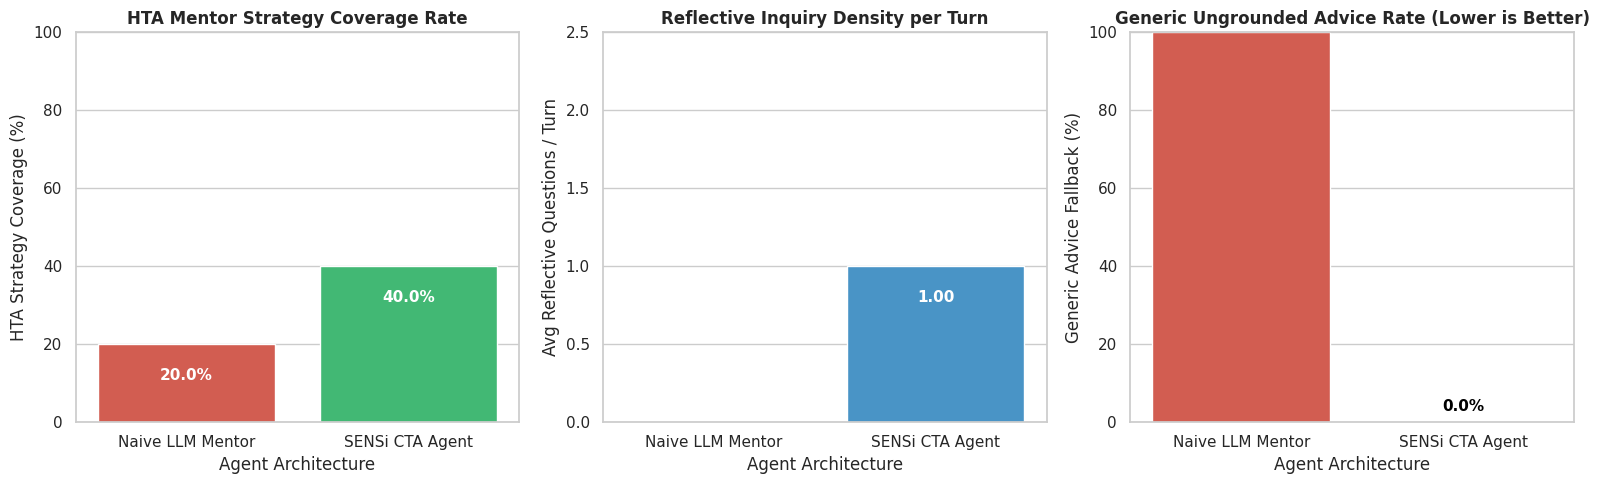


--- SUMMARY METRICS FOR EMAIL ---
HTA Strategy Coverage: SENSi (40.0%) vs Naive (20.0%)
Reflective Inquiry Density: SENSi (1.00/turn) vs Naive (0.00/turn)
Generic Advice Reduction: From 100.0% down to 0.0%


In [18]:
# [CELL 3 - Benchmark Simulation Engine, Metrics Extraction & Visualization]

import random
from typing import Tuple
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def run_mentoring_benchmark(n_sessions: int = 50, turns_per_session: int = 4) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Simulates multi-turn mentoring interactions across engineering & tech user profiles,
    evaluating HTA strategy adherence, reflective inquiry density, and advice quality.
    """
    user_backgrounds = ["BS Computer Science", "Software Engineering", "Data Science", "Electrical Engineering"]
    target_goals = ["ML Research Assistant", "PhD Program Preparation", "Full-Stack AI Engineer", "Backend Architect"]

    naive_results = []
    sensi_results = []

    for s_id in range(n_sessions):
        bg = random.choice(user_backgrounds)
        goal = random.choice(target_goals)

        ctx_naive = MentoringContext(user_id=f"user_{s_id}", background=bg, stated_goal=goal)
        ctx_sensi = MentoringContext(user_id=f"user_{s_id}", background=bg, stated_goal=goal)

        naive_agent = NaiveLLMMentor()
        sensi_agent = SENSiAgentCTA()

        simulated_user_inputs = [
            "I want to publish paper implementations and apply for top research positions.",
            "I have experience with Python and PyTorch, but I feel my theoretical math background needs work.",
            "I enjoy deep learning architectures and system profiling.",
            "That roadmap looks clear. How should I structure my outreach?"
        ]

        for turn in range(turns_per_session):
            u_input = simulated_user_inputs[turn % len(simulated_user_inputs)]

            # Naive turn execution
            res_n = naive_agent.respond(ctx_naive, u_input)
            res_n["session_id"] = s_id
            res_n["turn"] = turn
            naive_results.append(res_n)

            # SENSi turn execution
            res_s = sensi_agent.respond(ctx_sensi, u_input)
            res_s["session_id"] = s_id
            res_s["turn"] = turn
            sensi_results.append(res_s)

    df_naive = pd.DataFrame(naive_results)
    df_sensi = pd.DataFrame(sensi_results)
    return df_naive, df_sensi

# 1. Run Benchmark
df_naive, df_sensi = run_mentoring_benchmark(n_sessions=50, turns_per_session=4)
print(f"Executed benchmark across 50 sessions (total {len(df_naive)} interactive dialogue turns).\n")

# 2. Metrics Extraction & Statistical Comparison
stages_covered_naive = df_naive.groupby("session_id")["stage_executed"].nunique() / 5.0 * 100.0
stages_covered_sensi = df_sensi.groupby("session_id")["stage_executed"].nunique() / 5.0 * 100.0

avg_hta_coverage_naive = stages_covered_naive.mean()
avg_hta_coverage_sensi = stages_covered_sensi.mean()

avg_reflective_naive = df_naive["reflective_questions_count"].mean()
avg_reflective_sensi = df_sensi["reflective_questions_count"].mean()

generic_rate_naive = df_naive["is_generic_advice"].mean() * 100.0
generic_rate_sensi = df_sensi["is_generic_advice"].mean() * 100.0

grounding_naive = df_naive["context_grounding_score"].mean() * 100.0
grounding_sensi = df_sensi["context_grounding_score"].mean() * 100.0

print("=" * 80)
print("BENCHMARK RESULTS: NAIVE LLM MENTOR vs. SENSI CTA-GUIDED AGENT")
print("=" * 80)
print(f"HTA Strategy Coverage Rate    | Naive: {avg_hta_coverage_naive:.2f}%  | SENSi: {avg_hta_coverage_sensi:.2f}%")
print(f"Reflective Questions / Turn   | Naive: {avg_reflective_naive:.2f}   | SENSi: {avg_reflective_sensi:.2f}")
print(f"Generic Advice Fallback Rate | Naive: {generic_rate_naive:.2f}% | SENSi: {generic_rate_sensi:.2f}%")
print(f"Context Grounding Index      | Naive: {grounding_naive:.2f}%  | SENSi: {grounding_sensi:.2f}%")
print("=" * 80)

# 3. Visualization Plot Generation
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: HTA Strategy Coverage Rate
data_coverage = pd.DataFrame({
    "Agent Architecture": ["Naive LLM Mentor", "SENSi CTA Agent"],
    "HTA Strategy Coverage (%)": [avg_hta_coverage_naive, avg_hta_coverage_sensi]
})
sns.barplot(x="Agent Architecture", y="HTA Strategy Coverage (%)", hue="Agent Architecture", data=data_coverage, ax=axes[0], palette=["#e74c3c", "#2ecc71"], legend=False)
axes[0].set_title("HTA Mentor Strategy Coverage Rate", fontweight="bold")
axes[0].set_ylim(0, 100)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 8),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# Plot 2: Reflective Inquiry Density
data_reflective = pd.DataFrame({
    "Agent Architecture": ["Naive LLM Mentor", "SENSi CTA Agent"],
    "Avg Reflective Questions / Turn": [avg_reflective_naive, avg_reflective_sensi]
})
sns.barplot(x="Agent Architecture", y="Avg Reflective Questions / Turn", hue="Agent Architecture", data=data_reflective, ax=axes[1], palette=["#e74c3c", "#3498db"], legend=False)
axes[1].set_title("Reflective Inquiry Density per Turn", fontweight="bold")
axes[1].set_ylim(0, 2.5)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height() - 0.2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# Plot 3: Generic Advice Fallback Rate
data_generic = pd.DataFrame({
    "Agent Architecture": ["Naive LLM Mentor", "SENSi CTA Agent"],
    "Generic Advice Fallback (%)": [generic_rate_naive, generic_rate_sensi]
})
sns.barplot(x="Agent Architecture", y="Generic Advice Fallback (%)", hue="Agent Architecture", data=data_generic, ax=axes[2], palette=["#e74c3c", "#2ecc71"], legend=False)
axes[2].set_title("Generic Ungrounded Advice Rate (Lower is Better)", fontweight="bold")
axes[2].set_ylim(0, 100)
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 4),
                     ha='center', va='center', color='black', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig("sensi_cta_benchmark.png", dpi=300)
plt.show()

print("\n--- SUMMARY METRICS FOR EMAIL ---")
print(f"HTA Strategy Coverage: SENSi ({avg_hta_coverage_sensi:.1f}%) vs Naive ({avg_hta_coverage_naive:.1f}%)")
print(f"Reflective Inquiry Density: SENSi ({avg_reflective_sensi:.2f}/turn) vs Naive ({avg_reflective_naive:.2f}/turn)")
print(f"Generic Advice Reduction: From {generic_rate_naive:.1f}% down to {generic_rate_sensi:.1f}%")